# Trabalho 5

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import Image
from matplotlib.animation import FuncAnimation

# local imports
sys.path.append(os.path.abspath(r"../util/"))


from geometry import Segment, Pose, Angle
from robot import Robot
from maps import ObstacleMap, OccupancyGrid
from range_finder import RangeFinders
from control import VelocityControl, generateConstantVelocityTrajectory


In [3]:
#initialize environment and map
env = ObstacleMap(
    [
        Segment((-5, 5), (5, 5)),
        Segment((5, -5), (5, 5)),
        Segment((-5, 5), (-5, -4)),

        Segment((-5, -4), (-4, -4)),
        Segment((-4, -5), (-4, -4)),
        Segment((-5, -1), (-3, -1)),

        Segment((-3, 2.5), (-1, 2.5)),
        Segment((-2, 1.5), (-2, 3.5)),
        Segment((0.5, 5), (2, 1)),

        Segment((3, 3), (3, 5)),
        Segment((4, 1), (5, 1)),
        Segment((-1, -1), (0, -1)),

        Segment((0, -1), (0, -5)),
        Segment((1.5, -1.5), (3.5, -3.5)),
        Segment((1.5, -3.5), (3.5, -1.5)),
    ],
    x_lims=(-5, 5),
    y_lims=(-5, 5)
)

o_grid_resolution = 0.1
x_roi = (-5,5)
y_roi = (-5,5)
o_grid = OccupancyGrid(x_roi, y_roi, o_grid_resolution)

In [4]:
#set initial position
x0 = Pose(0., 0., Angle.from_deg(0.))

#set dt for simulation
dt = 0.05

In [17]:
#define sensor:
front_left   = Pose(0, 0.5, Angle(np.pi/6))
front_right  = Pose(0, -0.5, Angle(- np.pi/6))
front_center = Pose(0.5, 0, Angle(0.))
back_left    = Pose(-0.5, 0, Angle(np.pi - np.pi/6))
back_right   = Pose(-0.5, 0, Angle(np.pi + np.pi/6))

range_finder = RangeFinders(
    [
        front_left,
        front_right,
        front_center,
        back_left,
        back_right,        
    ],
    beam_fov=Angle.from_deg(2),
    robot_pose=x0
)

min_dist_to_wall = 1.2
v_max = 2
w_max = np.pi / 4
w_rotate = np.pi / 6
rotate_angle_when_in_front_of_obstacle = np.pi / 6
rot_time = rotate_angle_when_in_front_of_obstacle / w_rotate
rot_sign = 1
iter_to_rotate =  rot_time / dt
rotated_iter = iter_to_rotate

#implement collision avoidance
def collisionAvoidance(u: VelocityControl):
    global range_finder, min_dist_to_wall, v_max, w_max, rotate_angle_when_in_front_of_obstacle, rotated_iter, iter_to_rotate, w_rotate

    k_fl = 10
    k_bl = 0.1
    k_fr = 10
    k_br = 0.
    k_fc = 1.2
    k_bc = 0.

    min_dist_to_rot = 0.1

    def zero_clip(val, clip_val):
        if val > clip_val: return 0
        else: return val

    if rotated_iter < iter_to_rotate:
        u.w = w_rotate
        u.v = 0
        rotated_iter += 1
    else:
        fl = zero_clip(range_finder.z_rangers[0].reading.r, min_dist_to_wall)
        fr = zero_clip(range_finder.z_rangers[1].reading.r, min_dist_to_wall)
        fc = zero_clip(range_finder.z_rangers[2].reading.r, min_dist_to_wall)
        bl = zero_clip(range_finder.z_rangers[3].reading.r, min_dist_to_wall)
        br = zero_clip(range_finder.z_rangers[4].reading.r, min_dist_to_wall)
        bc = zero_clip(np.sqrt(br**2 + bl**2) / 2,          min_dist_to_wall)

        if (fl > 1e-6 and fl < np.cos(np.pi/6) + min_dist_to_rot) or (fr > 1e-6 and fr < np.cos(np.pi/6) + min_dist_to_rot) or (fc > 1e-6 and fc < min_dist_to_rot):
            rotated_iter = 0
            rot_sign = np.sign(-u.w) + (u.w == 0)
            u.w = w_rotate
            u.v = 0

            return u

        fl = min_dist_to_wall - fl if fl > 0. else 0 
        fr = min_dist_to_wall - fr if fr > 0. else 0 
        fc = min_dist_to_wall - fc if fc > 0. else 0 
        bl = min_dist_to_wall - bl if bl > 0. else 0 
        br = min_dist_to_wall - br if br > 0. else 0 
        bc = min_dist_to_wall - bc if bc > 0. else 0 

        turn_right = k_fl * fl + k_bl * bl
        turn_left  = k_fr * fr + k_br * br

        w_corr = turn_left - turn_right
        v_corr = k_bc * bc - k_fc * fc

        v_new = np.clip(u.v + v_corr, 0., v_max)
        w_new = np.clip(u.w + w_corr, -w_max, w_max)

        if v_new < 1e-6 and u.v > 1e-6: 
            rotated_iter = 0
            rot_sign = np.sign(w_new) + (w_new == 0)
            u.w = w_rotate * rot_sign
            u.v = 0
        else:
            u.w = w_new
            u.v = v_new

    return u


In [18]:
#define the robot
robot = Robot(
    x0, 
    sensors = [
        range_finder
    ],
    collisionAvoidance = collisionAvoidance 
)

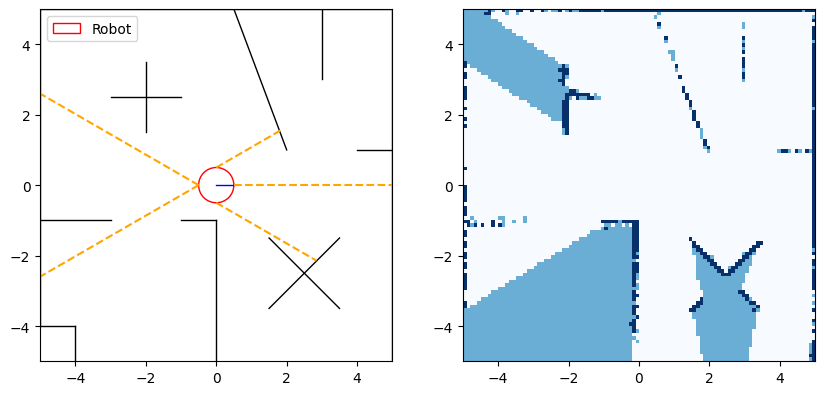

In [19]:
#plot initial state, with first measurement
f = plt.figure(figsize=(10, 5))

robot.measure(env)
range_finder.update_occupancy_grid(o_grid)

ax1 = plt.subplot(1,2, 1)
env.draw(ax1)
robot.draw(ax1, r = 0.5)

ax2 = plt.subplot(1,2, 2)
o_grid.drawImg(ax2)

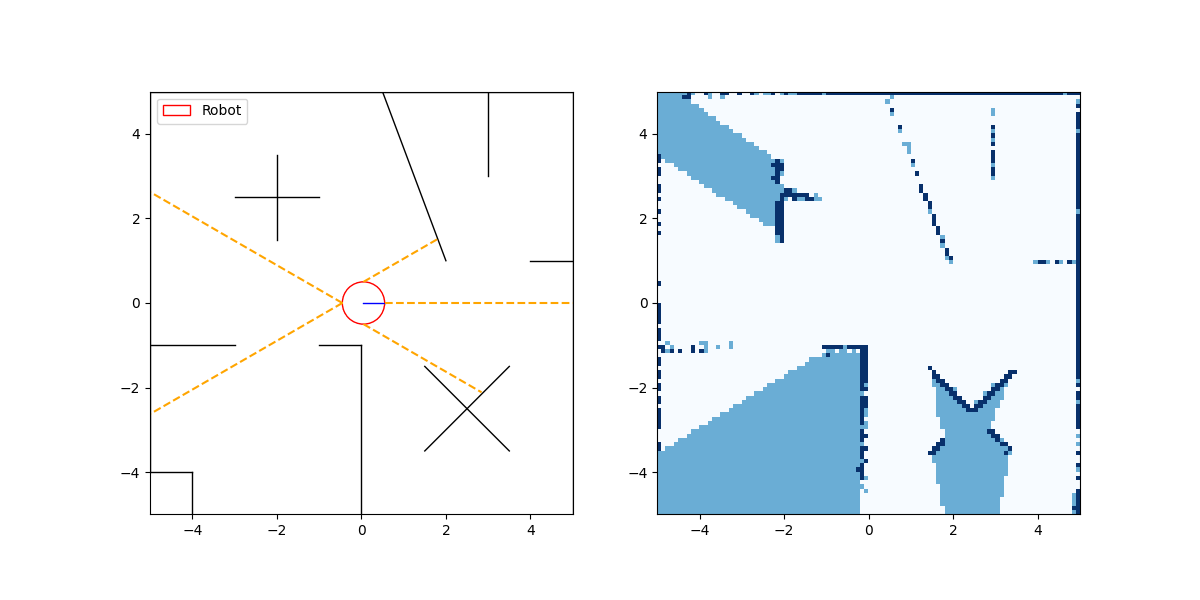

In [ ]:

animation_time = 30 #[s]

n_frames = int(animation_time / dt)
#trajectory = generateRandomVelocityTrajectory(n_frames,dt)
trajectory = generateConstantVelocityTrajectory(n_frames, 0.5, 0., dt)
applied_controls = []

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

env.draw(ax1)
ax1.set_aspect('equal', adjustable='box')
ax1.set_title("Map of Landmarks")
ax1.set_xlabel("$x$ [m]")
ax1.set_ylabel("$y$ [m]")
#update function for animation
def update(frame):
    global applied_controls
    ax2.clear()
    ax1.clear()
    
    u = trajectory[frame]

    applied_controls.append(robot.applyControl(u))

    robot.measure(env)
    range_finder.update_occupancy_grid(o_grid)

    env.draw(ax1)
    robot.draw(ax1, r = 0.5)

    o_grid.drawImg(ax2)
    

ani = FuncAnimation(fig, update, frames=np.arange(0, n_frames), interval=50)

gif_path = 'img/knownCorr.gif'
ani.save(gif_path, writer='pillow', fps=20)

plt.close(fig)

display(Image(filename=gif_path))